In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# ১. ডেটা তৈরি
data = {
    'Age': [22, 45, 34, 50, 23, 38, 58, 21, 42, 31],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'City': ['Dhaka', 'Chittagong', 'Sylhet', 'Dhaka', 'Chittagong', 'Sylhet', 'Dhaka', 'Sylhet', 'Chittagong', 'Dhaka'],
    'Annual_Income': [30000, 80000, 55000, 95000, 25000, 60000, 110000, 28000, 85000, 52000],
    'Subscription': [0, 1, 1, 1, 0, 1, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# ২. One-Hot Encoding (Gender এবং City কলামের জন্য)
encoder = OneHotEncoder(sparse_output=False) # sparse_output=False দিলে সরাসরি অ্যারে পাওয়া যায়
categorical_cols = df[['Gender', 'City']]
encoded_data = encoder.fit_transform(categorical_cols)

# ৩. এনকোড করা কলামগুলোকে বাকি ডেটার সাথে জোড়া লাগানো (Concatenation)
# Age এবং Annual_Income কলামের সাথে নতুন এনকোড করা কলামগুলো যোগ করছি
numerical_data = df[['Age', 'Annual_Income']].values
X = np.hstack([numerical_data, encoded_data]) # কলামগুলো পাশাপাশি জোড়া লাগলো
y = df['Subscription']

# ৪. Feature Scaling (KNN-এর জন্য সব কলাম স্কেল করা জরুরি)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ৫. মডেল ট্রেনিং
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

# ৬. নতুন কাস্টমারের প্রেডিকশন
# কাস্টমার: Age=30, Income=85000, Gender='Male', City='Dhaka'
new_cat = encoder.transform([['Male', 'Dhaka']]) # ক্যাটাগরি এনকোড করা
new_num = [[30, 85000]] # সংখ্যাগুলো
new_input = np.hstack([new_num, new_cat]) # সব ইনপুট একসাথে জোড়া লাগানো
new_input_scaled = scaler.transform(new_input) # স্কেলিং করা

result = knn.predict(new_input_scaled)

print(f"Buying status: {'কিনবেন' if result[0] == 1 else 'কিনবেন না'}")

Buying status: কিনবেন


c:\Users\Uthoaingyo\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.neighbors import KNeighborsClassifier

data={
    'Study_Hours':[10,2,8,1,9,3],
    'Attendence':['High', 'Low', 'Medium', 'Low', 'High', 'Medium'],
    'Previous_Score':[80, 40, 70, 30, 90, 45],
    'Result':[1, 0, 1, 0, 1, 0]
}
df=pd.DataFrame(data)

UnscaleData=df[['Study_Hours','Previous_Score']]
ScaleData=df[['Attendence']]

encoded=OneHotEncoder(sparse_output=False)
encoded_data=encoded.fit_transform(ScaleData)

std=StandardScaler()
scaler=std.fit_transform(UnscaleData)

X=np.hstack([encoded_data,scaler])
y=df['Result']

knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X,y)

newData=[[5,50]]

newstatus=encoded.transform([['Medium']])
pre_scaling=std.transform(newstatus)
pre_pridic=np.hstack([newData,pre_scaling])


result=knn.predict(pre_scaling)

print(f"If a student read 5,He will be {"Pass"if result[0]==1 else "Fail"}")

c:\Users\Uthoaingyo\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\Uthoaingyo\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 3 features, but StandardScaler is expecting 2 features as input.

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

data = {
    'Study_Hours': [10, 2, 8, 1, 9, 3],
    'Attendance': ['High', 'Low', 'Medium', 'Low', 'High', 'Medium'],
    'Previous_Score': [80, 40, 70, 30, 90, 45],
    'Result': [1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# ১. ডাটা আলাদা করা
num_data = df[['Study_Hours', 'Previous_Score']] # এগুলো স্কেল করতে হবে
cat_data = df[['Attendance']]                   # এগুলো এনকোড করতে হবে

# ২. এনকোডিং করা (Attendance)
encoded = OneHotEncoder(sparse_output=False)
encoded_data = encoded.fit_transform(cat_data)

# ৩. স্কেলিং করা (Study_Hours, Previous_Score)
std = StandardScaler()
scaled_num_data = std.fit_transform(num_data)

# ৪. ট্রেনিং এর জন্য X তৈরি করা (মনে রাখুন ক্রম: প্রথমে এনকোড, তারপর স্কেল)
X = np.hstack([encoded_data, scaled_num_data])
y = df['Result']

# ৫. মডেল ট্রেনিং
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

# --- নতুন স্টুডেন্ট প্রেডিকশন ---
# নতুন ডাটা: Study_Hours=5, Attendance='Medium', Previous_Score=50

# ৬. নতুন ক্যাটাগরি এনকোড করা
new_cat_status = encoded.transform([['Medium']])

# ৭. নতুন সংখ্যা স্কেল করা (এখানেই আপনার ভুল ছিল, std.transform শুধু সংখ্যার ওপর হবে)
new_num_data = [[5, 50]]
new_num_scaled = std.transform(new_num_data)

# ৮. এনকোড এবং স্কেল করা ডাটা ঠিক আগের (X এর) ক্রমে জোড়া লাগানো
final_input = np.hstack([new_cat_status, new_num_scaled])

# ৯. প্রেডিকশন
result = knn.predict(final_input)

print(f"Result: {'Pass' if result[0] == 1 else 'Fail'}")

c:\Users\Uthoaingyo\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\Uthoaingyo\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Result: Fail


In [1]:
# Step 1: লাইব্রেরি ইমপোর্ট
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 2: ডেটাসেট তৈরি
data = {
    'study_hours': [2, 5, 7, 1, 4, 6, 8, 3],
    'sleep_hours': [7, 6, 5, 8, 7, 6, 5, 7],
    'result': ['Fail', 'Pass', 'Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Fail']
}
df = pd.DataFrame(data)

# Step 3: Features (X) আর Target (y) আলাদা করা
X = df[['study_hours', 'sleep_hours']]
y = df['result']

# Step 4: Label Encoding (Pass=1, Fail=0)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7: Algorithm (Logistic Regression)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Step 8: Prediction
y_pred = model.predict(X_test_scaled)

# Step 9: Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

iris=load_iris()
X,y=iris.data,iris.target

encoder = LabelEncoder()
y=encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Iris Accuracy:", accuracy_score(y_test, y_pred)*100)

Iris Accuracy: 100.0


In [ ]:
# Problem 01 Smartwatch Data

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
data1 = {
    'Age': [25, 45, 30, 50, 22, 60, 35, 28, 55, 40],
    'Heart_Rate': [120, 70, 115, 65, 130, 62, 110, 75, 68, 105]
}
target1 = ['Exercising', 'Resting', 'Exercising', 'Resting', 'Exercising', 
           'Resting', 'Exercising', 'Resting', 'Resting', 'Exercising']

df1 = pd.DataFrame(data1)

X=df1[['Age','Heart_Rate']]
y='target1'

encoded=LabelEncoder()
y_encoded=encoded.fit_transform(target1)

MinMax=MinMaxScaler()
X_scaled=MinMax.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X_scaled,y_encoded,trian_size=0.2,random_state=42)

model=SVC()
model.fit(X_train,y_train)

print(f"accuracy_score:{accuracy_score(y_test,X_pre)}")

Data0={'Age':[10],'Heart_Rate':[60]}
data=pd.DataFrame(Data0)
ex=MinMax.transform(data)
print(ex)

modPre=model.predict(ex)
fresult=encoded.inverse_transform(modPre)
print(fresult[0])




[[-0.31578947 -0.02941176]]
Resting


ValueError: Found input variables with inconsistent numbers of samples: [3, 1]

In [22]:
# Problem 02 (Bank loan data)
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,MinMaxScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

data2 = {
    'Job': ['Engineer', 'Doctor', 'Clerk', 'Engineer', 'Doctor', 'Clerk', 'Engineer', 'Clerk'],
    'Education': ['University', 'University', 'School', 'College', 'University', 'College', 'University', 'School'],
    'Income': [80000, 120000, 30000, 75000, 110000, 45000, 95000, 25000]
}
target2 = ['Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No']

df2 = pd.DataFrame(data2)

encoded=OrdinalEncoder()
ore=encoded.fit_transform(df2[['Job']])

OnhEncoder=OneHotEncoder()
onh=OnhEncoder.fit_transform(df2[['Education']])

scaler=MinMaxScaler()
scValue=scaler.fit_transform(df2[['Income']])

x=np.vstack([ore,onh,scValue])

lable=LabelEncoder()
y=lable.fit_transform(['target2'])

X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.2,random_state=42)


ValueError: Found input variables with inconsistent numbers of samples: [10, 1]

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ১. ডাটা তৈরি (Dataset Creation)
data1 = {
    'Age': [25, 45, 30, 50, 22, 60, 35, 28, 55, 40],
    'Heart_Rate': [120, 70, 115, 65, 130, 62, 110, 75, 68, 105]
}
target1 = ['Exercising', 'Resting', 'Exercising', 'Resting', 'Exercising', 
           'Resting', 'Exercising', 'Resting', 'Resting', 'Exercising']

X = pd.DataFrame(data1)

# ২. Labeling (Target-কে ০ এবং ১-এ রূপান্তর)
le = LabelEncoder()
y = le.fit_transform(target1) 

# ৩. Scaling (দূরত্ব-ভিত্তিক অ্যালগরিদমের জন্য এটি বাধ্যতামূলক)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ৪. Train-Test Split (৮০% ট্রেনিং, ২০% টেস্টিং)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ৫. Algorithm Fit (KNN ব্যবহার করে)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# ৬. Accuracy Check (মডেল কতটুকু নির্ভুল তা যাচাই)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"মডেলের নির্ভুলতা (Accuracy): {accuracy * 100}%")

# --- অতিরিক্ত অংশ যা সমাধানটিকে পূর্ণাঙ্গ করবে ---

# ৭. নতুন ডেটা দিয়ে প্রেডিকশন (New Data Prediction)
# ধরো একজন নতুন ব্যক্তির বয়স ৩৫ এবং হার্টরেট ১১৫। তিনি কি করছেন?
new_data = pd.DataFrame({'Age': [35], 'Heart_Rate': [60]})

# মনে রাখবে: নতুন ডেটাকেও একই স্কেলার দিয়ে স্কেল করতে হবে
new_data_scaled = scaler.transform(new_data)

# প্রেডিকশন করা
prediction = knn.predict(new_data_scaled)

# ৮. সংখ্যাকে আবার টেক্সটে রূপান্তর (Inverse Transform)
# ০ বা ১ না দেখিয়ে সরাসরি 'Exercising' বা 'Resting' দেখানো
result = le.inverse_transform(prediction)

print(f"নতুন ডেটার ফলাফল: {result[0]}")

মডেলের নির্ভুলতা (Accuracy): 100.0%
নতুন ডেটার ফলাফল: Resting


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import numpy as np

# ১. ডাটা তৈরি
data2 = {
    'Job': ['Engineer', 'Doctor', 'Clerk', 'Engineer', 'Doctor', 'Clerk', 'Engineer', 'Clerk'],
    'Education': ['University', 'University', 'School', 'College', 'University', 'College', 'University', 'School'],
    'Income': [80000, 120000, 30000, 75000, 110000, 45000, 95000, 25000]
}
target2 = ['Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No']
df2 = pd.DataFrame(data2)

# ২. Ordinal Encoding (Education-এর জন্য র‍্যাঙ্ক অনুযায়ী)
edu_order = ['School', 'College', 'University']
ord_enc = OrdinalEncoder(categories=[edu_order])
df2['Education'] = ord_enc.fit_transform(df2[['Education']])

# ৩. OneHot Encoding (Job-এর জন্য কারণ এখানে কোনো র‍্যাঙ্ক নেই)
# সহজ করার জন্য pandas get_dummies ব্যবহার করা যায়
df2 = pd.get_dummies(df2, columns=['Job'])

# ৪. Target Labeling
y2 = le.fit_transform(target2)
X2 = df2

# ৫. Algorithm Fit
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X2, y2)
print("Problem 2: Model Trained Successfully!")

Problem 2: Model Trained Successfully!


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ১. ডাটা তৈরি
data3 = {
    'Time_on_App': [12.5, 10.2, 15.1, 9.8, 14.5, 11.2, 13.8, 10.5],
    'Length_of_Membership': [3.5, 2.1, 5.2, 1.5, 4.8, 2.5, 4.1, 2.0],
    'Avg_Session_Length': [32.5, 31.2, 34.8, 30.5, 33.1, 32.0, 33.5, 31.8]
}
y3 = [550, 410, 620, 380, 590, 450, 570, 400]
X3 = pd.DataFrame(data3)

# ২. Scaling (Linear Regression-এ স্কেলিং করলে মডেল দ্রুত শেখে)
X3_scaled = scaler.fit_transform(X3)

# ৩. Algorithm Fit
lr = LinearRegression()
lr.fit(X3_scaled, y3)

# ৪. Prediction & Error Check
y_pred = lr.predict(X3_scaled)
mse = mean_squared_error(y3, y_pred)
print(f"Problem 3 Mean Squared Error: {mse}")

Problem 3 Mean Squared Error: 240.9646982608656


In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# data_dist = {
#     'Weight_gram': [140, 130, 150, 170, 155, 160, 145, 165,170,167],
#     'Texture_Score': [7, 8, 7, 2, 3, 2, 8, 3,5,6] # ১-১০ স্কেলে মসৃণতা
# }
# y_dist = ['Apple', 'Apple', 'Apple', 'Avogado', 'Orange', 'Orange', 'Apple', 'Orange','Avogado','Orange']

data_dist = {
    'Weight_gram': [
        140, 130, 145, 135, 142, 148, 138, 141, 146, 132, # Apples
        160, 165, 170, 155, 158, 162, 168, 157, 159, 164, # Oranges
        180, 190, 185, 175, 195, 182, 188, 178, 192, 184  # Avocados
    ],
    'Texture_Score': [
        7, 8, 8, 7, 9, 7, 8, 7, 8, 9, # Apples (High score)
        3, 2, 4, 3, 2, 5, 3, 4, 2, 3, # Oranges (Low score)
        5, 6, 5, 7, 6, 5, 6, 7, 5, 6  # Avocados (Medium score)
    ]
}

y_dist = (['Apple'] * 10) + (['Orange'] * 10) + (['Avogado'] * 10)
df2 = pd.DataFrame(data_dist)

scaler=OrdinalEncoder()
X=scaler.fit_transform(df2[['Weight_gram','Texture_Score']])

encoder=LabelEncoder()
y=encoder.fit_transform(y_dist)

X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.75,random_state=42)

model=KNeighborsClassifier(n_neighbors=1)
model.fit(X_train,y_train)

predicValue=model.predict(X_test)
value=encoder.inverse_transform(predicValue)
print(value)

pf1=pd.DataFrame({'Weight_gram':[180],'Texture_Score':[6]})
x1=scaler.transform(pf1)

pred=model.predict(x1)

print("Pridic fruit:",encoder.inverse_transform(pred)[0])
print("accurecy:",accuracy_score(y_test,predicValue)*100)




['Avogado' 'Orange' 'Avogado' 'Orange' 'Apple' 'Apple' 'Avogado' 'Avogado']
Pridic fruit: Avogado
accurecy: 100.0


In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data_tree = {
    'Age': [22, 45, 30, 55, 20, 35, 50, 25, 28, 40, 
            60, 19, 33, 48, 26, 38, 52, 23, 42, 31, 
            29, 44, 21, 58, 36, 46, 24, 39, 53, 27, 
            34, 49, 32, 56, 41, 47, 22, 43, 37, 51, 
            54, 20, 59, 35, 45, 25, 30, 55, 18, 62],
    
    'Has_Job': ['No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
                'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
                'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No',
                'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes',
                'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No'],
    
    'Income': [15000, 120000, 45000, 95000, 12000, 65000, 85000, 25000, 35000, 75000,
               110000, 10000, 55000, 90000, 22000, 68000, 88000, 18000, 82000, 50000,
               42000, 98000, 14000, 105000, 72000, 87000, 20000, 78000, 92000, 26000,
               60000, 94000, 52000, 102000, 80000, 89000, 16000, 84000, 70000, 91000,
               96000, 11000, 108000, 67000, 115000, 24000, 48000, 97000, 5000, 12000]
}

y_tree = ['No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
          'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
          'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No',
          'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes',
          'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No']

df3 = pd.DataFrame(data_tree)

encoder=OneHotEncoder(sparse_output=False)
X_encode=encoder.fit_transform(df3[['Has_Job']])

encoded=LabelEncoder()
y=encoded.fit_transform(y_tree)

scaler=MinMaxScaler()
X_scaler=scaler.fit_transform(df3[['Income','Age']])

X=np.concatenate((X_scaler,X_encode),axis=1)

X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

model=RandomForestClassifier()
model.fit(X_train,y_train)

pred_Value=model.predict(X_test)

print(encoded.inverse_transform(pred_Value))
print("Pridiction Accurecy:",accuracy_score(y_test,pred_Value)*100)

['Yes' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes']
Pridiction Accurecy: 100.0


In [4]:
import pandas as pd
from sklearn.cluster import KMeans

# ডাটাসেট: বার্ষিক আয় এবং শপিং স্কোর
data_kmeans = {
    'Annual_Income': [15, 16, 17, 70, 72, 75, 120, 125, 130],
    'Spending_Score': [80, 85, 78, 45, 50, 48, 15, 20, 18]
}
df2 = pd.DataFrame(data_kmeans)

# টিপস: এখানে কোনো Target (y) লাগবে না। model.fit(df2) দিলেই হবে।

model=KMeans(n_clusters=3, random_state=42)
model.fit(df2)

result=model.predict(pd.DataFrame({'Annual_Income':[30],'Spending_Score':[150]}))
print(result)

[2]


ক্লাস্টারসহ ডেটাফ্রেম:
   Annual_Income  Spending_Score  Cluster
0             15              80        2
1             16              85        2
2             17              78        2
3             70              45        0
4             72              50        0
5             75              48        0
6            120              15        1
7            125              20        1
8            130              18        1


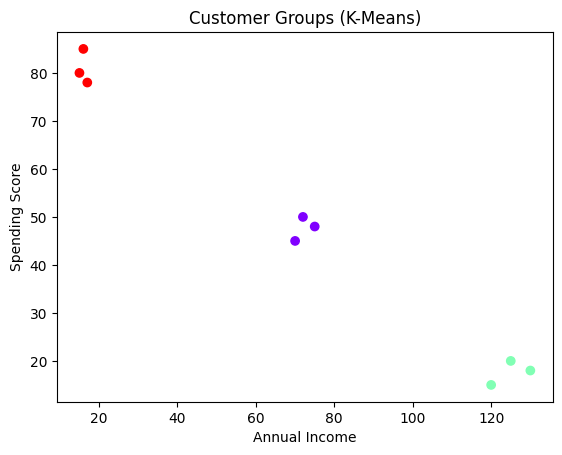

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ১. ডাটা তৈরি
data_kmeans = {
    'Annual_Income': [15, 16, 17, 70, 72, 75, 120, 125, 130],
    'Spending_Score': [80, 85, 78, 45, 50, 48, 15, 20, 18]
}
df = pd.DataFrame(data_kmeans)

# ২. স্কেলিং (K-Means দূরত্বের ওপর ভিত্তি করে কাজ করে, তাই এটি জরুরি)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# ৩. মডেল তৈরি এবং ফিট করা
# ধরো আমরা কাস্টমারদের ৩টি গ্রুপে (n_clusters=3) ভাগ করতে চাই
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)

# ৪. প্রেডিকশন (কারা কোন গ্রুপে পড়েছে তা দেখা)
df['Cluster'] = kmeans.labels_

print("ক্লাস্টারসহ ডেটাফ্রেম:")
print(df)

# ৫. গ্রাফের মাধ্যমে দেখা (Visualization)
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'], cmap='rainbow')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Groups (K-Means)')
plt.show()

In [7]:
from sklearn.decomposition import PCA

# আমাদের কাছে ৩টি ফিচার আছে (উচ্চতা, ওজন, বয়স)
data_complex = {
    'Height': [170, 160, 180, 150, 175],
    'Weight': [70, 60, 90, 50, 85],
    'Age': [25, 30, 45, 22, 35]
}
df_complex = pd.DataFrame(data_complex)

# ১. স্কেলিং
scaled_complex = scaler.fit_transform(df_complex)

# ২. PCA প্রয়োগ (৩টি কলাম থেকে ২টিতে নামিয়ে আনা)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_complex)

# ৩. নতুন ডাটাফ্রেম তৈরি
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
print("\nPCA রেজাল্ট (৩টি কলাম এখন ২টি):")
print(df_pca)


PCA রেজাল্ট (৩টি কলাম এখন ২টি):
        PC1       PC2
0 -0.316546 -0.768805
1 -0.910033  0.387023
2  2.388011  0.416032
3 -2.395258  0.232121
4  1.233826 -0.266371


In [8]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# ১. Scikit-learn-এর ভেতরে থাকা ডিজিট ডাটা লোড করা
digits = datasets.load_digits()

# ২. ছবিগুলোকে ফ্ল্যাট করে সংখ্যায় রূপান্তর (৮x৮ ছবিকে ৬৪টি কলামে নেওয়া)
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# ৩. মডেল ট্রেনিং
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.5)
model = SVC(gamma=0.001)
model.fit(X_train, y_train)

# এখন মডেলটি একটি নতুন ছবি দেখে বলতে পারবে সেটা কত নম্বর!

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
